In [1]:
import json, os, re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from thermoift.PLOT_SETTINGS import (
    plot_init, style_legend, save_plot,
    colors, markers, face_colors,
    markersize, markeredgewidth, capsize,
    linewidth, label_fontsize, legend_fontsize, legend_boxwidth,
    tick_labelsize,
)

In [2]:
BASE      = "/home/darshan/A6/PCSAFT_cDFT/PART_2/snellius-scratch"
SIZES     = [25, 50, 75, 100]
SIZE_DIRS = {25: "N025", 50: "N050", 75: "N075", 100: "N100"}

TARGET_CFG = [
    ("P_bubble", "Bubble", "Bubble", "TabPFN_P_bubble_metrics.json"),
    ("gamma",    "Gamma",  "Gamma",  "TabPFN_gamma_metrics.json"),
]

In [3]:
_ARR_RE = re.compile(r"\[([\.\d\s\+\-eE]+)\]")

def _cell_output_text(cell):
    texts = []
    for out in cell.get('outputs', []):
        text = out.get('text', out.get('data', {}).get('text/plain', ''))
        if isinstance(text, list):
            text = ''.join(text)
        texts.append(text)
    return '\n'.join(texts)


def extract_cv_from_notebook(nb_path):
    """Return (cv_r2_scores, cv_rmse_scores, cv_mae_scores) arrays from a trial output notebook."""
    with open(nb_path) as fh:
        nb = json.load(fh)
    r2_scores = rmse_scores = mae_scores = None
    for cell in nb['cells']:
        if cell['cell_type'] != 'code':
            continue
        if 'cross_validate' not in ''.join(cell['source']):
            continue
        txt = _cell_output_text(cell)
        if not txt:
            continue
        for line in txt.splitlines():
            m = _ARR_RE.search(line)
            if m is None:
                continue
            arr = np.fromstring(m.group(1), sep=' ')
            if len(arr) != 5:
                continue
            if 'R\u00b2' in line or 'R2' in line or 'r2' in line.lower():
                r2_scores = arr
            elif 'RMSE' in line or 'rmse' in line.lower():
                rmse_scores = arr
            elif 'MAE' in line or 'mae' in line.lower():
                mae_scores = arr
    if r2_scores is None or rmse_scores is None:
        return None
    return r2_scores, rmse_scores, mae_scores


def extract_cv_from_json(json_path):
    """Read cv scores from a saved metrics JSON."""
    with open(json_path) as fh:
        m = json.load(fh)
    mae = np.array(m['cv_mae_scores']) if 'cv_mae_scores' in m else None
    return np.array(m['cv_r2_scores']), np.array(m['cv_rmse_scores']), mae


In [4]:
#Collect per-trial CV data from all notebooks

rows = []

# ── RANDOM (trial_00 … trial_19) ─────────────────────────────────────────────
RANDOM_BASE = os.path.join(BASE, "RANDOM", "OUTPUTS")

for size in SIZES:
    sdir = SIZE_DIRS[size]
    for target, nb_tag, folder, jname in TARGET_CFG:
        for trial in range(20):
            nb_path = os.path.join(
                RANDOM_BASE, sdir,
                f"TabPFN{nb_tag}_{sdir}_trial_{trial:02d}_output.ipynb"
            )
            if not os.path.exists(nb_path):
                continue
            result = extract_cv_from_notebook(nb_path)
            if result is None:
                print(f"  [skip — no CV output] {nb_path.split('/')[-1]}")
                continue
            r2, rmse, mae = result
            rows.append(dict(
                method="Random", N_train=size, trial=trial, target=target,
                cv_r2_mean=float(r2.mean()),     cv_r2_std=float(r2.std()),
                cv_rmse_mean=float(rmse.mean()), cv_rmse_std=float(rmse.std()),
                cv_mae_mean=float(mae.mean()) if mae is not None else None,
                cv_mae_std=float(mae.std())   if mae is not None else None,
            ))

print(f"  Random rows collected: {sum(1 for r in rows if r['method']=='Random')}")


  Random rows collected: 160


In [5]:
# ── STRATIFIED (trial_00 … trial_19) ────────────────────────────────────────
STRAT_BASE = os.path.join(BASE, "STRATIFIED", "OUTPUTS")

for size in SIZES:
    sdir = SIZE_DIRS[size]
    for target, nb_tag, folder, jname in TARGET_CFG:
        for trial in range(20):
            nb_path   = os.path.join(STRAT_BASE, sdir, f"TabPFN{nb_tag}_{sdir}_trial_{trial:02d}_output.ipynb")
            json_path = os.path.join(STRAT_BASE, sdir, folder, jname)

            result = extract_cv_from_notebook(nb_path) if os.path.exists(nb_path) else None
            if result is None and trial == 0 and os.path.exists(json_path):
                result = extract_cv_from_json(json_path)
            if result is None:
                continue
            r2, rmse, mae = result
            rows.append(dict(
                method="Stratified", N_train=size, trial=trial, target=target,
                cv_r2_mean=float(r2.mean()),     cv_r2_std=float(r2.std()),
                cv_rmse_mean=float(rmse.mean()), cv_rmse_std=float(rmse.std()),
                cv_mae_mean=float(mae.mean()) if mae is not None else None,
                cv_mae_std=float(mae.std())   if mae is not None else None,
            ))

print(f"  Stratified rows collected: {sum(1 for r in rows if r['method']=='Stratified')}")


  Stratified rows collected: 160


In [6]:
# ── ACTIVE LEARNING — AL_ST (trial_00 … trial_19) ───────────────────────────
AL_ST_BASE = os.path.join(BASE, "ACTIVELEARNING", "OUTPUTS", "AL_ST")

for size in SIZES:
    sdir = SIZE_DIRS[size]
    for target, nb_tag, folder, jname in TARGET_CFG:
        for trial in range(20):
            nb_path = os.path.join(
                AL_ST_BASE, sdir,
                f"trial_{trial:02d}",
                f"TabPFN{nb_tag}_AL_ST_{sdir}_trial_{trial:02d}_output.ipynb"
            )
            if not os.path.exists(nb_path):
                print(f"  [missing] {nb_path.split('/')[-1]}")
                continue
            result = extract_cv_from_notebook(nb_path)
            if result is None:
                print(f"  [skip — no CV output] {nb_path.split('/')[-1]}")
                continue
            r2, rmse, mae = result
            rows.append(dict(
                method="AL-ST", N_train=size, trial=trial, target=target,
                cv_r2_mean=float(r2.mean()),   cv_r2_std=float(r2.std()),
                cv_rmse_mean=float(rmse.mean()), cv_rmse_std=float(rmse.std()),
                cv_mae_mean=float(mae.mean()) if mae is not None else None,
                cv_mae_std=float(mae.std())  if mae is not None else None,
            ))

print(f"  AL-ST rows collected: {sum(1 for r in rows if r['method']=='AL-ST')}")

  AL-ST rows collected: 160


In [7]:
# ── ACTIVE LEARNING — AL_MT (trial_00 … trial_19) ───────────────────────────
AL_MT_BASE = os.path.join(BASE, "ACTIVELEARNING", "OUTPUTS", "AL_MT")

for size in SIZES:
    sdir = SIZE_DIRS[size]
    for target, nb_tag, folder, jname in TARGET_CFG:
        for trial in range(20):
            nb_path = os.path.join(
                AL_MT_BASE, sdir,
                f"trial_{trial:02d}",
                f"TabPFN{nb_tag}_AL_MT_{sdir}_trial_{trial:02d}_output.ipynb"
            )
            if not os.path.exists(nb_path):
                print(f"  [missing] {nb_path.split('/')[-1]}")
                continue
            result = extract_cv_from_notebook(nb_path)
            if result is None:
                print(f"  [skip — no CV output] {nb_path.split('/')[-1]}")
                continue
            r2, rmse, mae = result
            rows.append(dict(
                method="AL-MT", N_train=size, trial=trial, target=target,
                cv_r2_mean=float(r2.mean()),   cv_r2_std=float(r2.std()),
                cv_rmse_mean=float(rmse.mean()), cv_rmse_std=float(rmse.std()),
                cv_mae_mean=float(mae.mean()) if mae is not None else None,
                cv_mae_std=float(mae.std())  if mae is not None else None,
            ))

print(f"  AL-MT rows collected: {sum(1 for r in rows if r['method']=='AL-MT')}")

  AL-MT rows collected: 160


## 2 · Save raw per-trial CSV

In [8]:
df_raw = pd.DataFrame(rows, columns=[
    "method", "N_train", "trial", "target",
    "cv_r2_mean",   "cv_r2_std",
    "cv_rmse_mean", "cv_rmse_std",
    "cv_mae_mean",  "cv_mae_std",
])
df_raw = df_raw.sort_values(["method", "target", "N_train", "trial"]).reset_index(drop=True)

os.makedirs(os.path.join(BASE, "PLOTS"), exist_ok=True)
csv_raw_path = os.path.join(BASE, "PLOTS", "cv_metrics_per_trial.csv")
df_raw.to_csv(csv_raw_path, index=False)
print(f"Saved {len(df_raw)} rows -->{csv_raw_path}")
print()
print(df_raw.groupby(["method", "target", "N_train"]).size().rename("n_trials").to_string())


Saved 640 rows -->/home/darshan/A6/PCSAFT_cDFT/PART_2/snellius-scratch/PLOTS/cv_metrics_per_trial.csv

method      target    N_train
AL-MT       P_bubble  25         20
                      50         20
                      75         20
                      100        20
            gamma     25         20
                      50         20
                      75         20
                      100        20
AL-ST       P_bubble  25         20
                      50         20
                      75         20
                      100        20
            gamma     25         20
                      50         20
                      75         20
                      100        20
Random      P_bubble  25         20
                      50         20
                      75         20
                      100        20
            gamma     25         20
                      50         20
                      75         20
                      100        20
Str

In [9]:
plot_rows = []

for (method, target, N_train), grp in df_raw.groupby(["method", "target", "N_train"]):
    n = len(grp)
    has_mae = grp['cv_mae_mean'].notna().any()
    if n > 1:
        r2_y,   r2_err   = grp['cv_r2_mean'].mean(),    grp['cv_r2_mean'].std(ddof=1)
        rmse_y, rmse_err = grp['cv_rmse_mean'].mean(),  grp['cv_rmse_mean'].std(ddof=1)
        mae_y   = grp['cv_mae_mean'].mean()  if has_mae else float('nan')
        mae_err = grp['cv_mae_mean'].std(ddof=1) if has_mae else float('nan')
    else:
        r2_y,   r2_err   = grp['cv_r2_mean'].iloc[0],   grp['cv_r2_std'].iloc[0]
        rmse_y, rmse_err = grp['cv_rmse_mean'].iloc[0], grp['cv_rmse_std'].iloc[0]
        mae_y   = grp['cv_mae_mean'].iloc[0] if has_mae else float('nan')
        mae_err = grp['cv_mae_std'].iloc[0]  if has_mae else float('nan')

    plot_rows.append(dict(
        method=method, target=target, N_train=N_train, n_trials=n,
        r2_y=r2_y,     r2_err=r2_err,
        rmse_y=rmse_y, rmse_err=rmse_err,
        mae_y=mae_y,   mae_err=mae_err,
    ))

df_plot = (
    pd.DataFrame(plot_rows)
    .sort_values(['target', 'method', 'N_train'])
    .reset_index(drop=True)
)

csv_agg_path = os.path.join(BASE, "PLOTS", "cv_metrics_aggregated.csv")
df_plot.to_csv(csv_agg_path, index=False)
print(f"Saved aggregated -->{csv_agg_path}")
df_plot


Saved aggregated -->/home/darshan/A6/PCSAFT_cDFT/PART_2/snellius-scratch/PLOTS/cv_metrics_aggregated.csv


,method,target,N_train,n_trials,r2_y,r2_err,rmse_y,rmse_err,mae_y,mae_err
0,AL-MT,P_bubble,25,20,0.929499,0.070292,6.776217,1.855567,3.565721,1.193869
1,AL-MT,P_bubble,50,20,0.975654,0.013516,4.131510,0.662905,2.047654,0.318361
2,AL-MT,P_bubble,75,20,0.986105,0.005123,3.163957,0.535094,1.491823,0.288377
3,AL-MT,P_bubble,100,20,0.993112,0.002994,2.334182,0.447167,1.038835,0.203922
4,AL-ST,P_bubble,25,20,0.932541,0.018641,8.259193,0.933617,6.393776,0.682002
5,AL-ST,P_bubble,50,20,0.978971,0.002982,4.734509,0.301979,3.375931,0.228674
6,AL-ST,P_bubble,75,20,0.988179,0.001258,3.413760,0.121357,2.450339,0.083927
7,AL-ST,P_bubble,100,20,0.991583,0.000820,2.790112,0.137085,2.030587,0.102717
8,Random,P_bubble,25,20,0.861770,0.058617,7.494506,1.963369,4.953921,1.028357
9,Random,P_bubble,50,20,0.957812,0.014328,4.499424,0.816999,2.869478,0.406047


R² plots below use raw aggregated `r2_y` / `r2_err` values from `df_plot`; no normalization is applied.

In [10]:
METHOD_ORDER   = ["Random", "Stratified", "AL-MT"]
METHOD_LABELS  = {"Random": r"$\mathrm{Random}$", "Stratified": r"$\mathrm{Stratified}$", "AL-MT": r"$\mathrm{AL}$"}

color_cycle    = [colors[0], colors[1], '#377eb8']
facecolor_cycle = [face_colors[0], face_colors[1], face_colors[2]]
marker_cycle   = markers[:len(METHOD_ORDER)]

FIGSIZE    = (4, 3)
BAR_WIDTH  = 4.0
markersize = 7

# Fontsizes scaled x1.2 (all math-rendered, same size)
LABEL_FS  = label_fontsize
LEGEND_FS = legend_fontsize * 1.2
TICK_FS   = tick_labelsize

## 5 · P_bubble plots

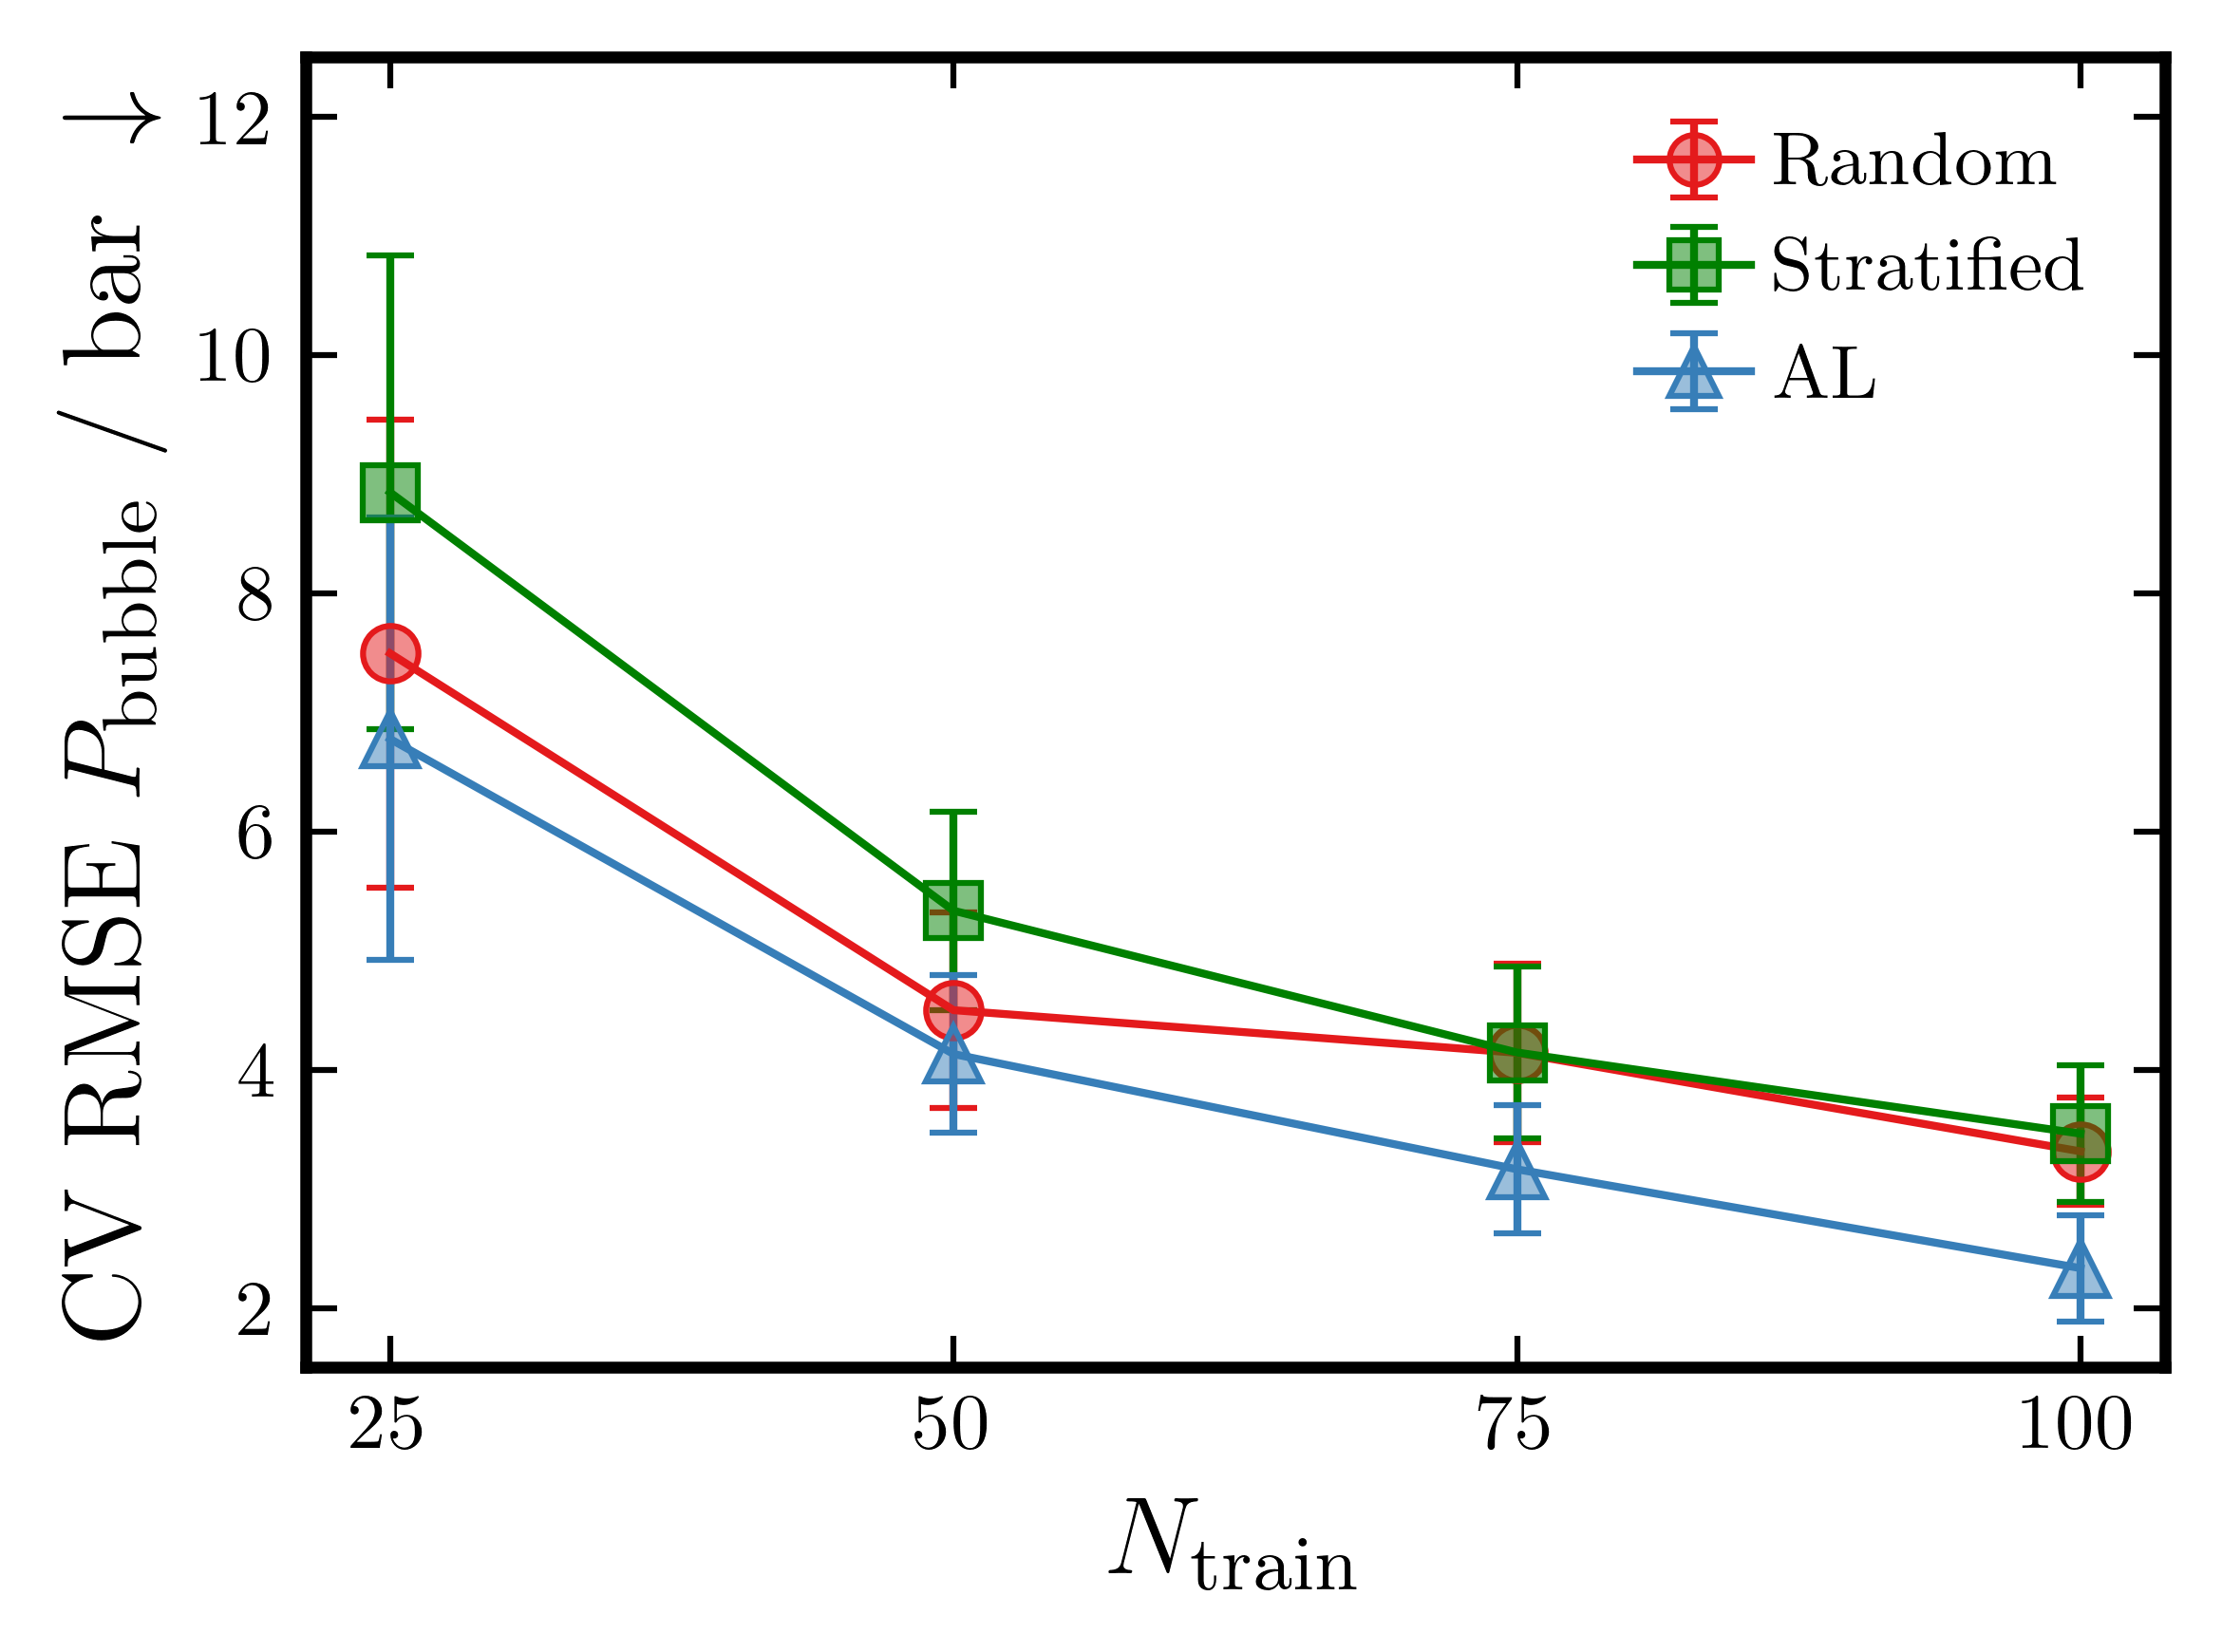

In [20]:
# CV RMSE — P_bubble
fig, ax = plot_init(w=4, h=3)
sub = df_plot[df_plot["target"] == "P_bubble"]

for i, method in enumerate(METHOD_ORDER):
    grp = sub[sub["method"] == method].sort_values("N_train")
    ax.errorbar(
        grp["N_train"].values, grp["rmse_y"].values, yerr=grp["rmse_err"].values,
        color=color_cycle[i], marker=marker_cycle[i], markersize=markersize,
        markeredgewidth=markeredgewidth, markeredgecolor=color_cycle[i],
        markerfacecolor=facecolor_cycle[i], linewidth=linewidth, linestyle='-',
        capsize=capsize, label=METHOD_LABELS[method],
    )

ax.set_xticks(SIZES)
ax.set_xlabel(r"$N_{\mathrm{train}}$", fontsize=LABEL_FS)
ax.set_ylabel(r"$\mathrm{CV\ RMSE}\ P_{\mathrm{bubble}}\ /\ \mathrm{bar}\ \downarrow$", fontsize=LABEL_FS)
ax.set_ylim(1.5, 12.5)  # shared y-axis across TabPFN/XGB for P_bubble RMSE
ax.set_yticks(np.arange(2, 13, 2))
ax.xaxis.set_minor_locator(plt.NullLocator())
ax.tick_params(axis='both', which='major', labelsize=TICK_FS)
style_legend(ax, loc="best", ncol=1, frame=False, fontsize=LEGEND_FS)
fig.tight_layout()
save_plot(fig, "cv_RMSE_Pbubble", folder=os.path.join(BASE, "PLOTS"))
plt.show()


Saved --> PLOTS/cv_R2_Pbubble.png / .pdf


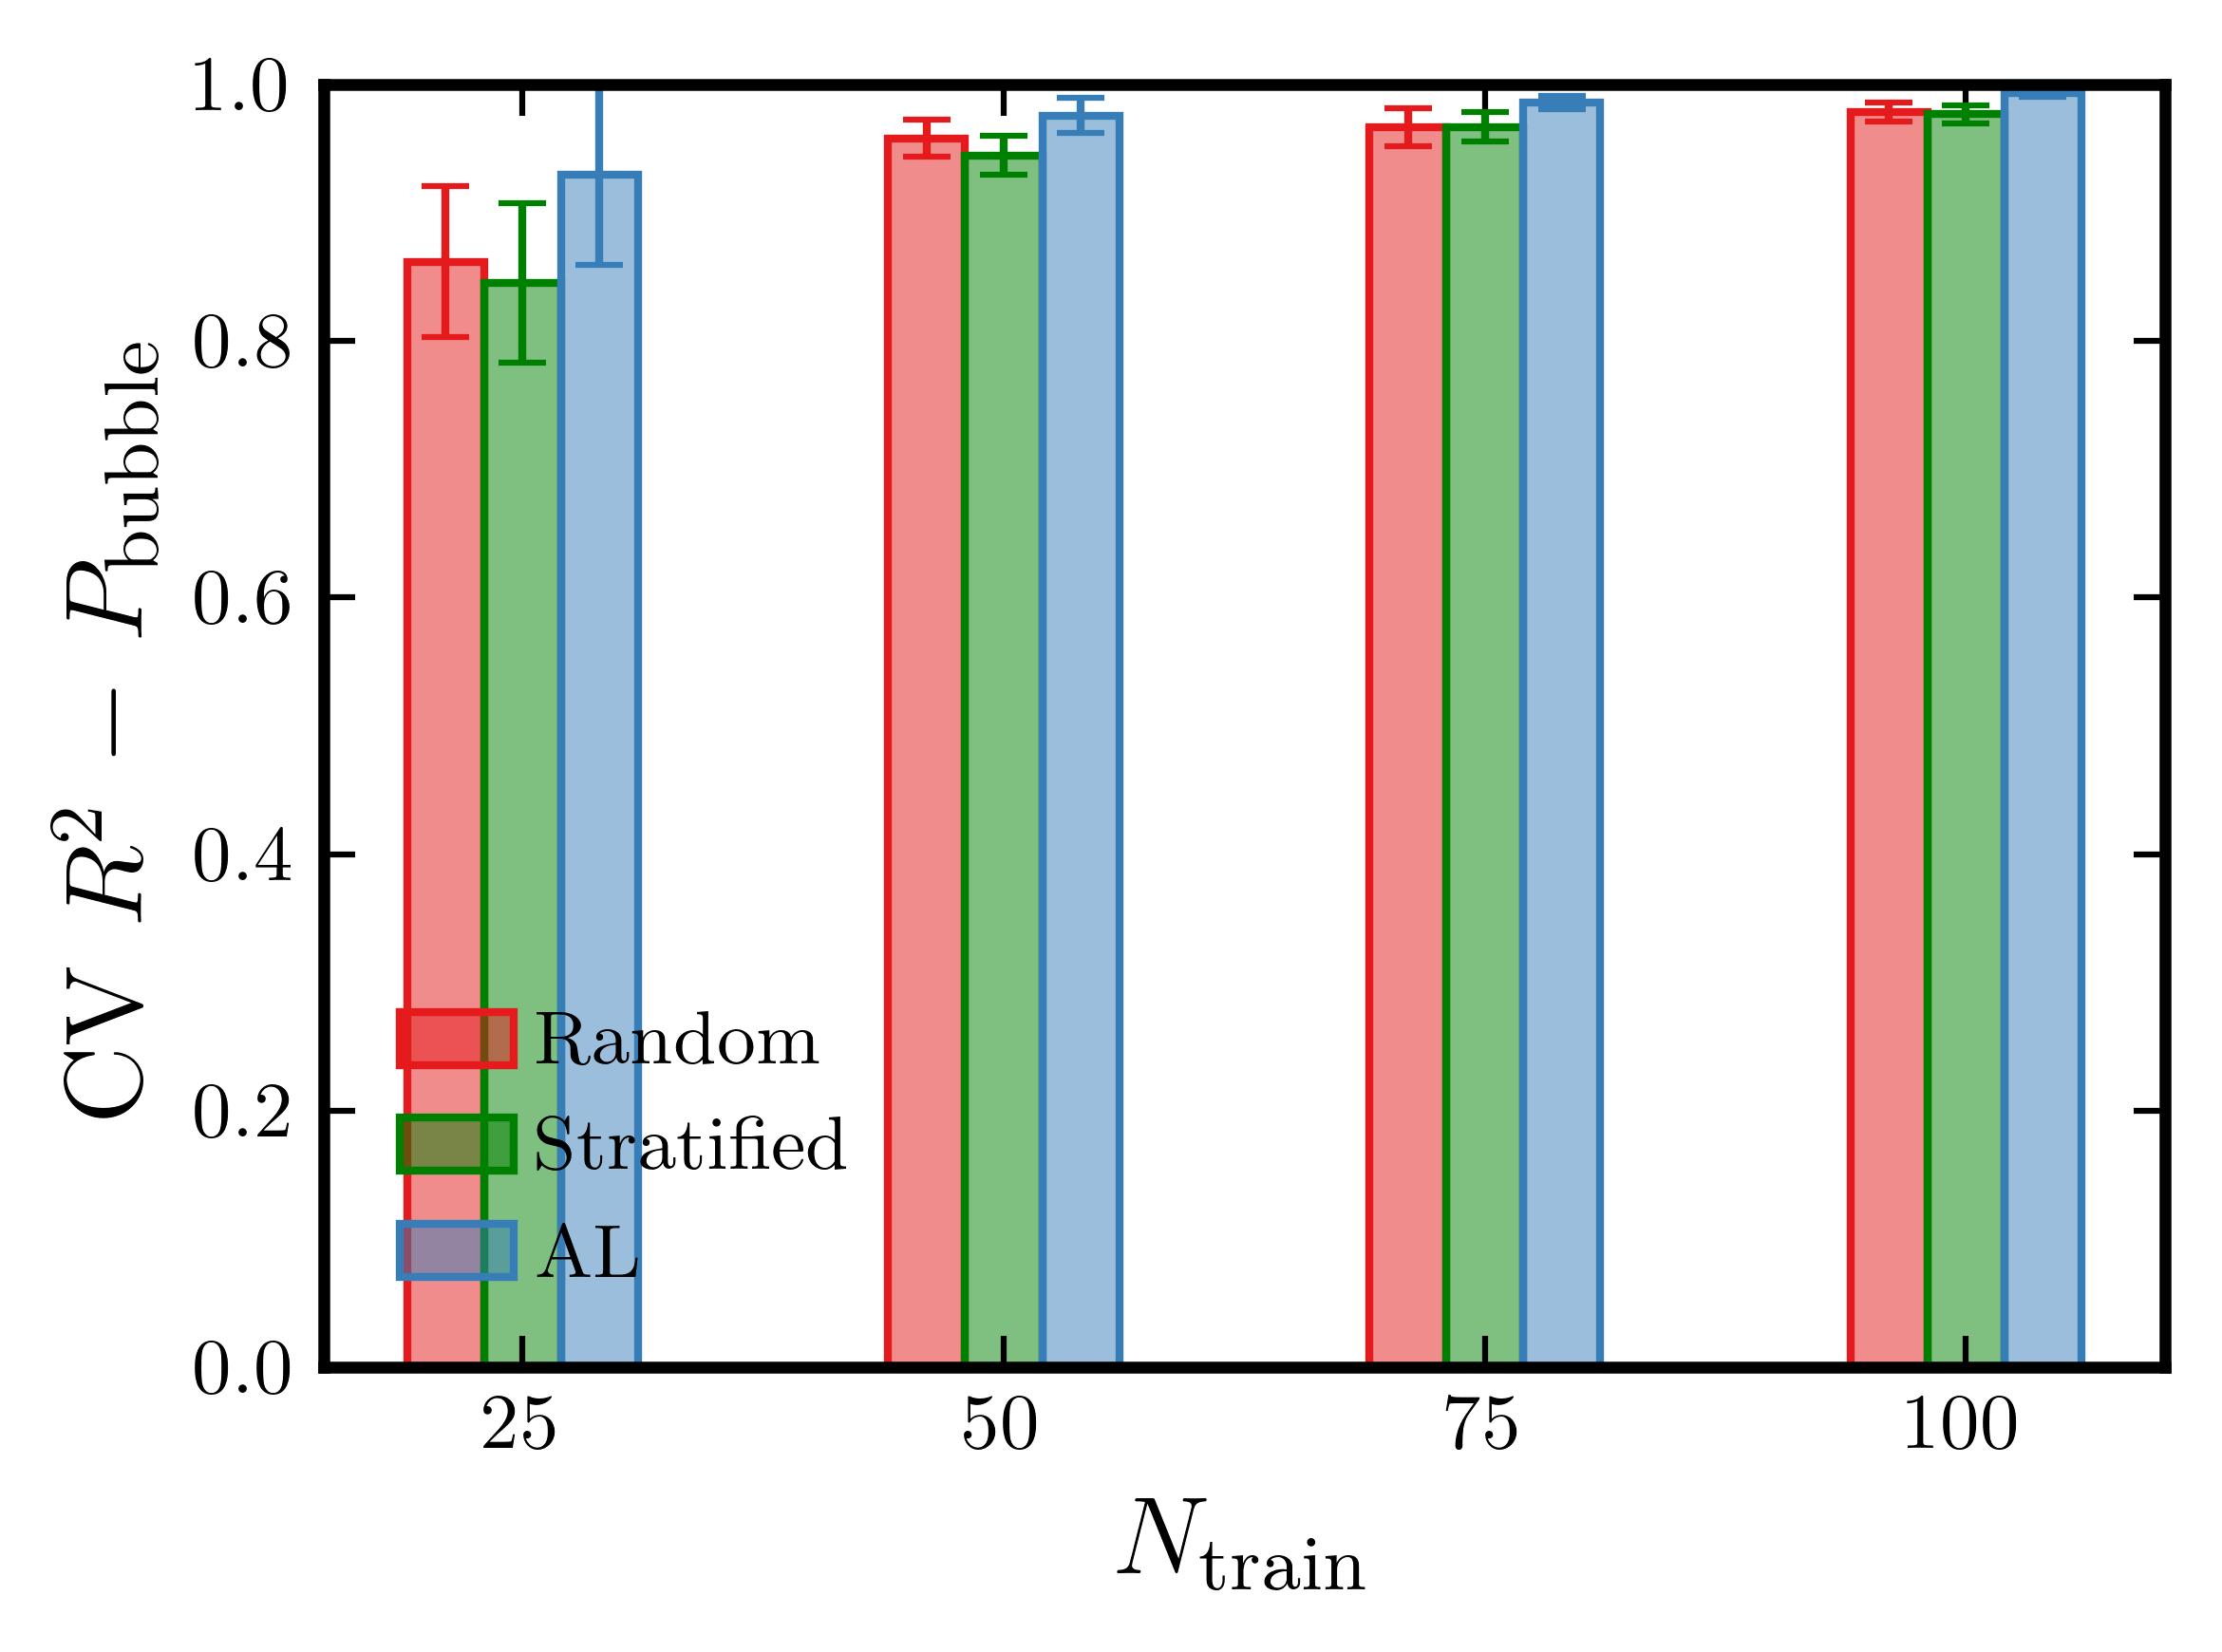

In [12]:
# CV R² — P_bubble, raw values, grouped bars
fig, ax = plot_init(w=4, h=3)
sub = df_plot[df_plot["target"] == "P_bubble"]

for i, method in enumerate(METHOD_ORDER):
    grp = sub[sub["method"] == method].sort_values("N_train")
    xs = grp["N_train"].values
    offset = (i - (len(METHOD_ORDER) - 1) / 2) * BAR_WIDTH

    ax.bar(
        xs + offset, grp["r2_y"].values, width=BAR_WIDTH,
        yerr=grp["r2_err"].values,
        color=facecolor_cycle[i], edgecolor=color_cycle[i], linewidth=linewidth,
        capsize=capsize,
        error_kw={"elinewidth": linewidth, "ecolor": color_cycle[i], "capthick": markeredgewidth},
        label=METHOD_LABELS[method],
    )

ax.set_xticks(SIZES)
ax.set_xlabel(r"$N_{\mathrm{train}}$", fontsize=LABEL_FS)
ax.set_ylabel(r"$\mathrm{CV}\ R^{2}\ {-}\ P_{\mathrm{bubble}}$", fontsize=LABEL_FS)
ax.set_ylim(0, 1)
ax.xaxis.set_minor_locator(plt.NullLocator())
ax.tick_params(axis='both', which='major', labelsize=TICK_FS)
style_legend(ax, loc="best", ncol=1, frame=False, fontsize=LEGEND_FS)
fig.tight_layout()
save_plot(fig, "cv_R2_Pbubble", folder=os.path.join(BASE, "PLOTS"))
print("Saved --> PLOTS/cv_R2_Pbubble.png / .pdf")
plt.show()

Saved --> PLOTS/cv_MAE_Pbubble.png / .pdf


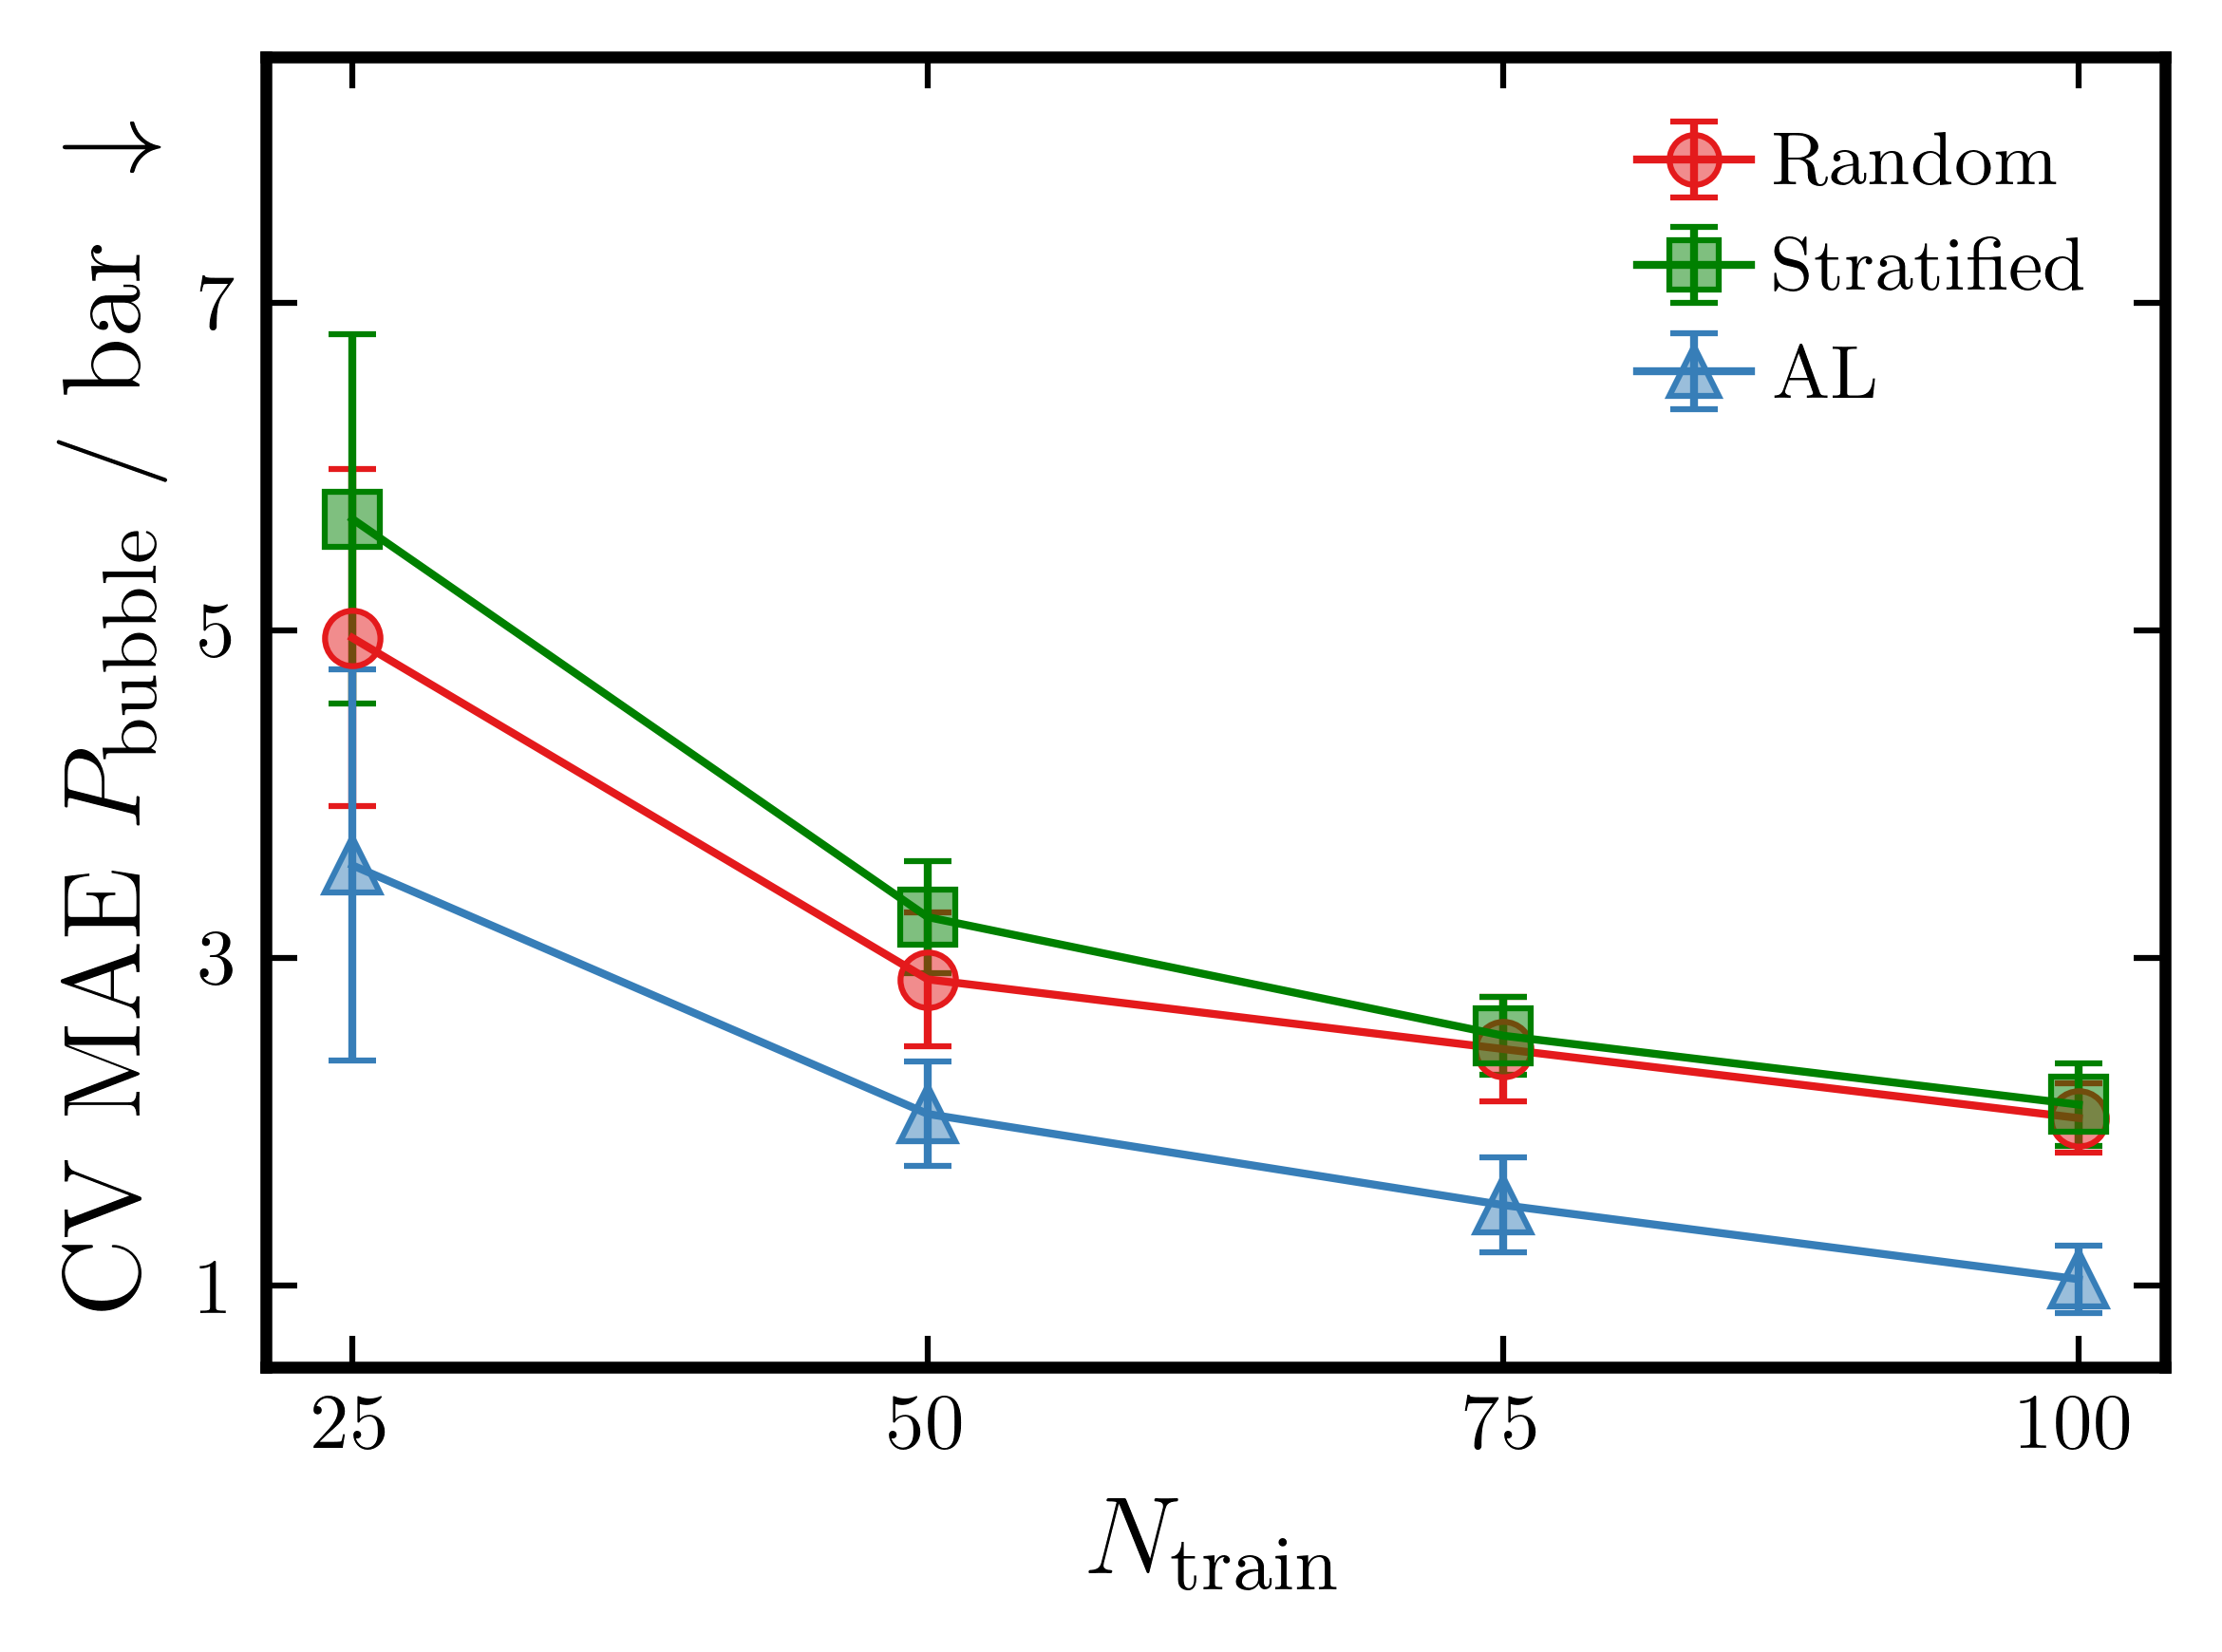

In [18]:
# CV MAE — P_bubble
fig, ax = plot_init(w=4, h=3)
sub = df_plot[df_plot["target"] == "P_bubble"]

for i, method in enumerate(METHOD_ORDER):
    grp = sub[sub["method"] == method].sort_values("N_train")
    grp = grp.dropna(subset=["mae_y", "mae_err"])
    if grp.empty:
        continue
    ax.errorbar(
        grp["N_train"].values, grp["mae_y"].values, yerr=grp["mae_err"].values,
        color=color_cycle[i], marker=marker_cycle[i], markersize=markersize,
        markeredgewidth=markeredgewidth, markeredgecolor=color_cycle[i],
        markerfacecolor=facecolor_cycle[i], linewidth=linewidth, linestyle='-',
        capsize=capsize, label=METHOD_LABELS[method],
    )

ax.set_xticks(SIZES)
ax.set_xlabel(r"$N_{\mathrm{train}}$", fontsize=LABEL_FS)
ax.set_ylabel(r"$\mathrm{CV\ MAE}\ P_{\mathrm{bubble}}\ /\ \mathrm{bar}\ \downarrow$", fontsize=LABEL_FS)
ax.set_ylim(0.5, 8.5)  # shared y-axis across TabPFN/XGB for P_bubble MAE
ax.set_yticks(np.arange(1, 9, 2))
ax.xaxis.set_minor_locator(plt.NullLocator())
ax.tick_params(axis='both', which='major', labelsize=TICK_FS)
style_legend(ax, loc="best", ncol=1, frame=False, fontsize=LEGEND_FS)
fig.tight_layout()
save_plot(fig, "cv_MAE_Pbubble", folder=os.path.join(BASE, "PLOTS"))
print("Saved --> PLOTS/cv_MAE_Pbubble.png / .pdf")
plt.show()


## 6 · γ (interfacial tension) plots

Saved --> PLOTS/cv_RMSE_gamma.png / .pdf


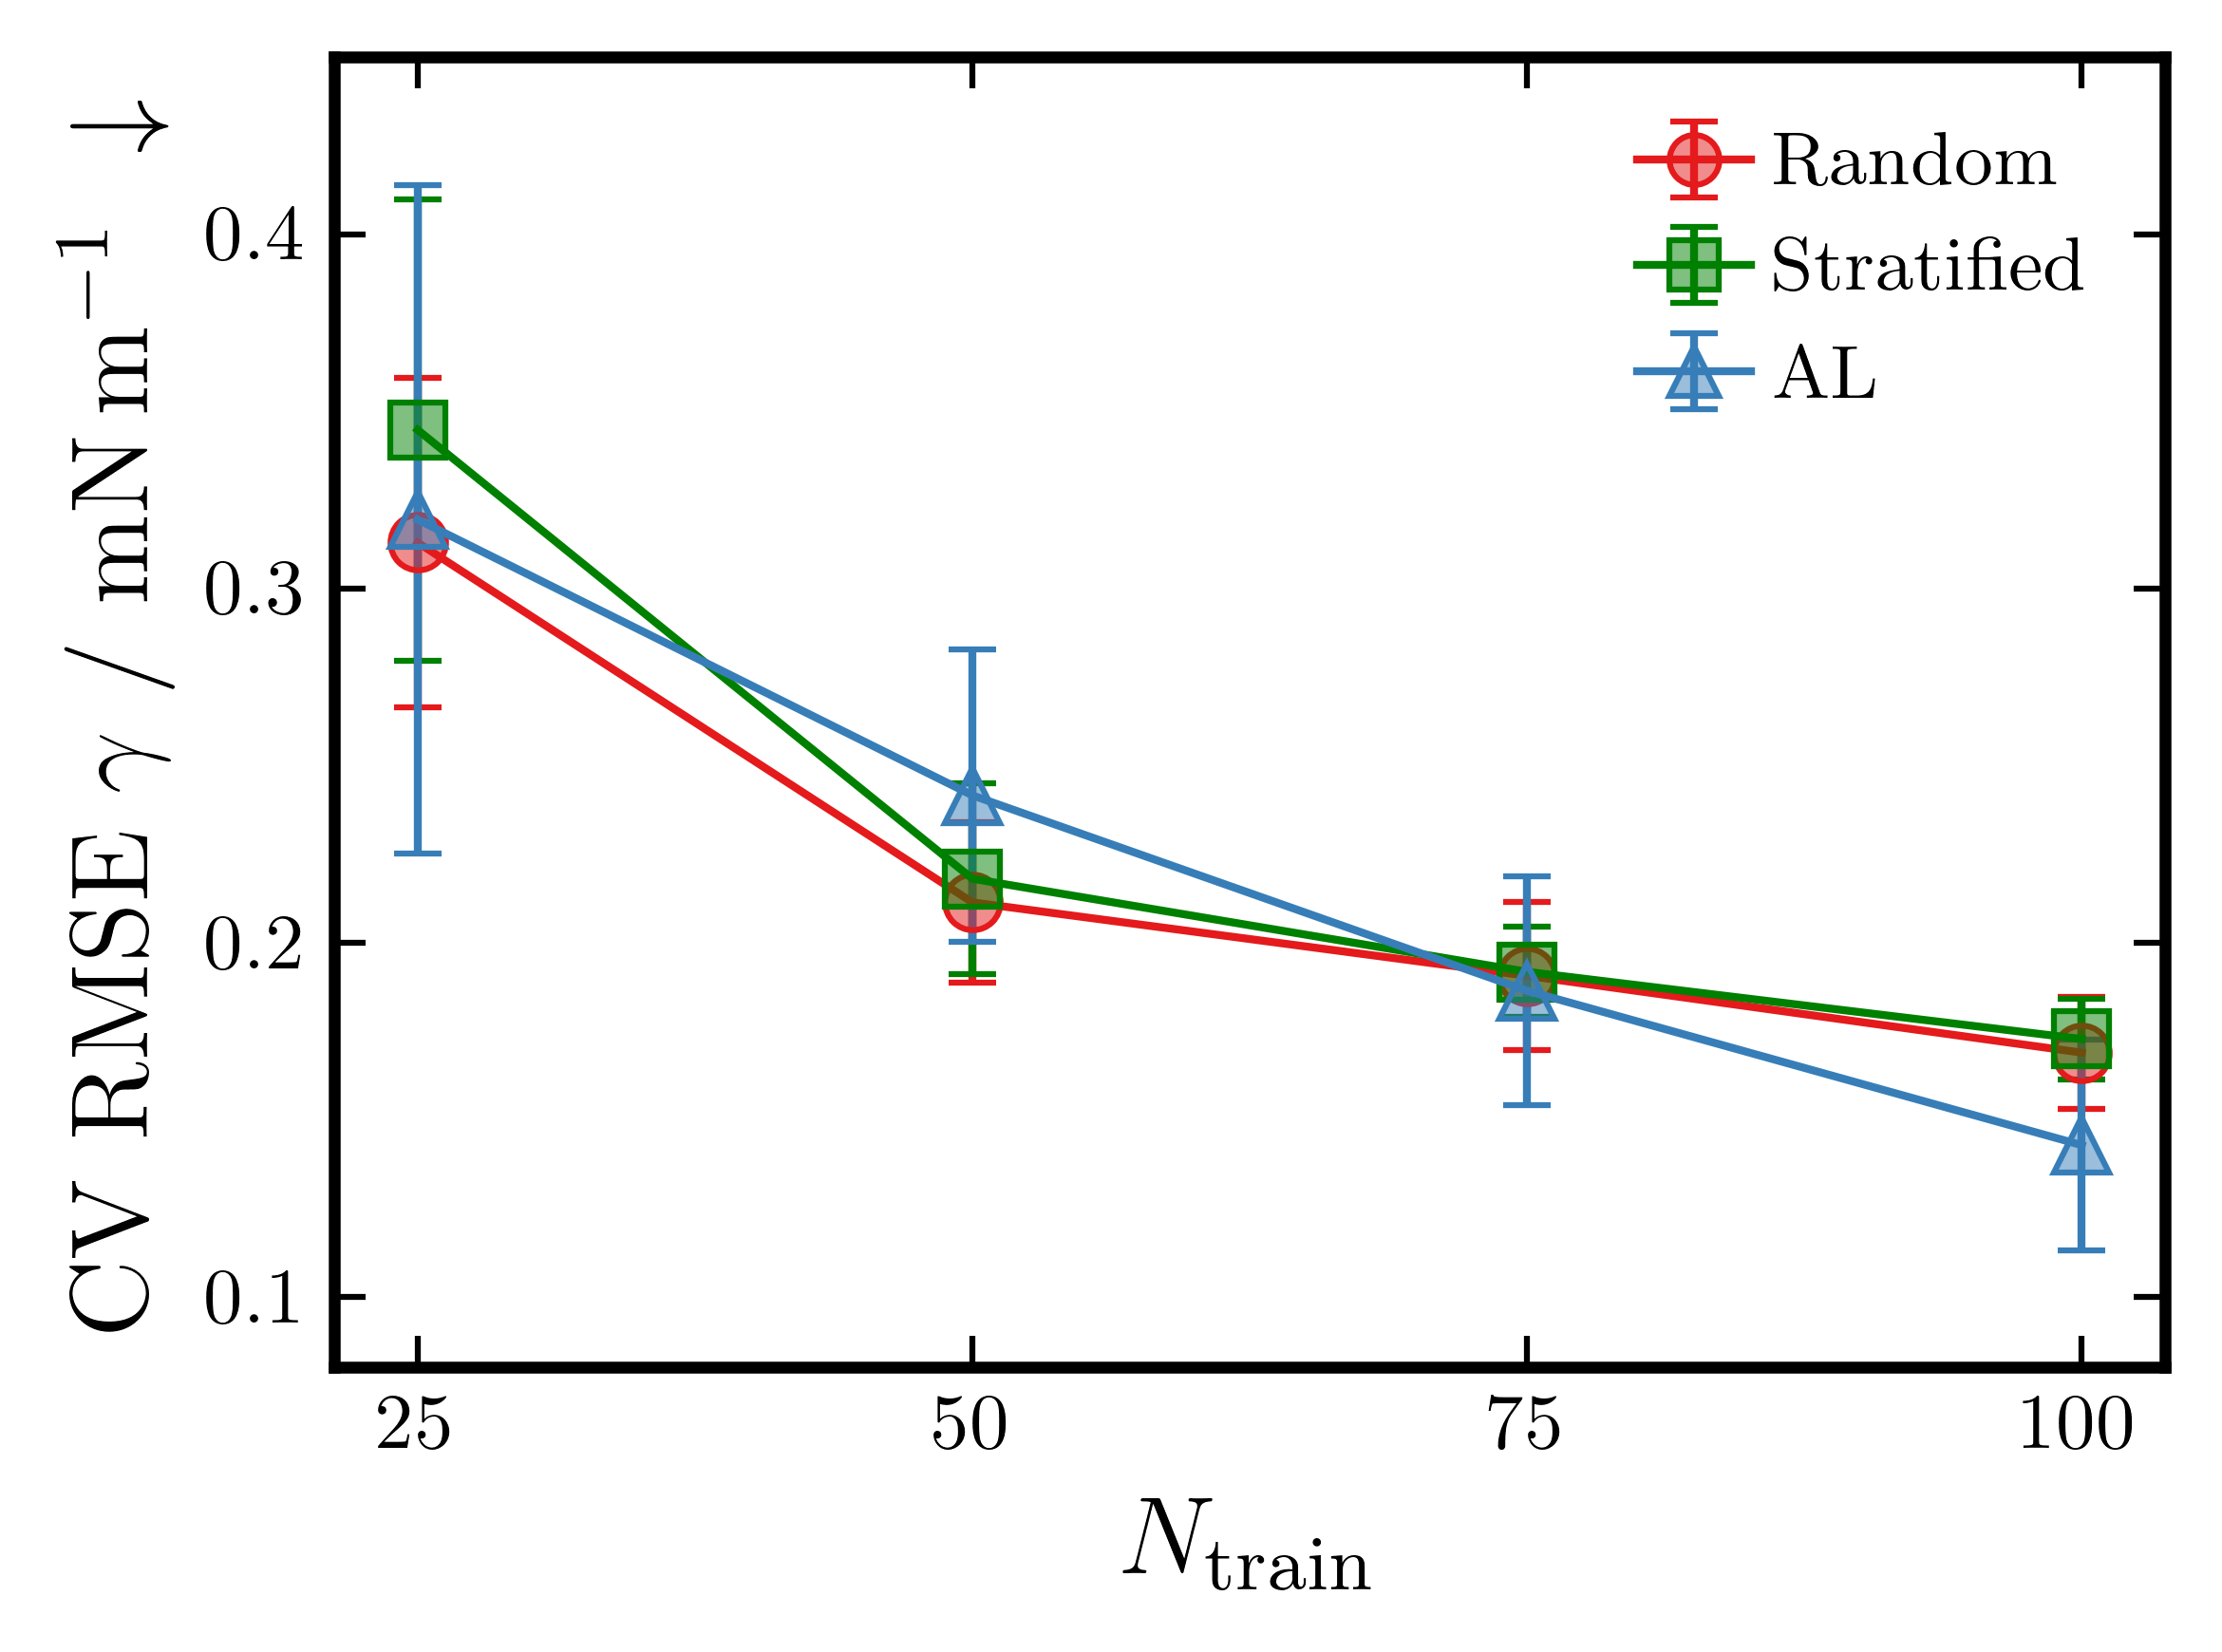

In [14]:
# CV RMSE — gamma
fig, ax = plot_init(w=4, h=3)
sub = df_plot[df_plot["target"] == "gamma"]

for i, method in enumerate(METHOD_ORDER):
    grp = sub[sub["method"] == method].sort_values("N_train")
    ax.errorbar(
        grp["N_train"].values, grp["rmse_y"].values, yerr=grp["rmse_err"].values,
        color=color_cycle[i], marker=marker_cycle[i], markersize=markersize,
        markeredgewidth=markeredgewidth, markeredgecolor=color_cycle[i],
        markerfacecolor=facecolor_cycle[i], linewidth=linewidth, linestyle='-',
        capsize=capsize, label=METHOD_LABELS[method],
    )

ax.set_xticks(SIZES)
ax.set_xlabel(r"$N_{\mathrm{train}}$", fontsize=LABEL_FS)
ax.set_ylabel(r"$\mathrm{CV\ RMSE}\ \gamma\ /\ \mathrm{mN}\,\mathrm{m}^{-1}\ \downarrow$", fontsize=LABEL_FS)
ax.set_ylim(0.08, 0.45)  # shared y-axis across TabPFN/XGB for gamma RMSE
ax.set_yticks(np.arange(0.1, 0.45, 0.1))
ax.xaxis.set_minor_locator(plt.NullLocator())
ax.tick_params(axis='both', which='major', labelsize=TICK_FS)
style_legend(ax, loc="best", ncol=1, frame=False, fontsize=LEGEND_FS)
fig.tight_layout()
save_plot(fig, "cv_RMSE_gamma", folder=os.path.join(BASE, "PLOTS"))
print("Saved --> PLOTS/cv_RMSE_gamma.png / .pdf")
plt.show()


Saved --> PLOTS/cv_R2_gamma.png / .pdf


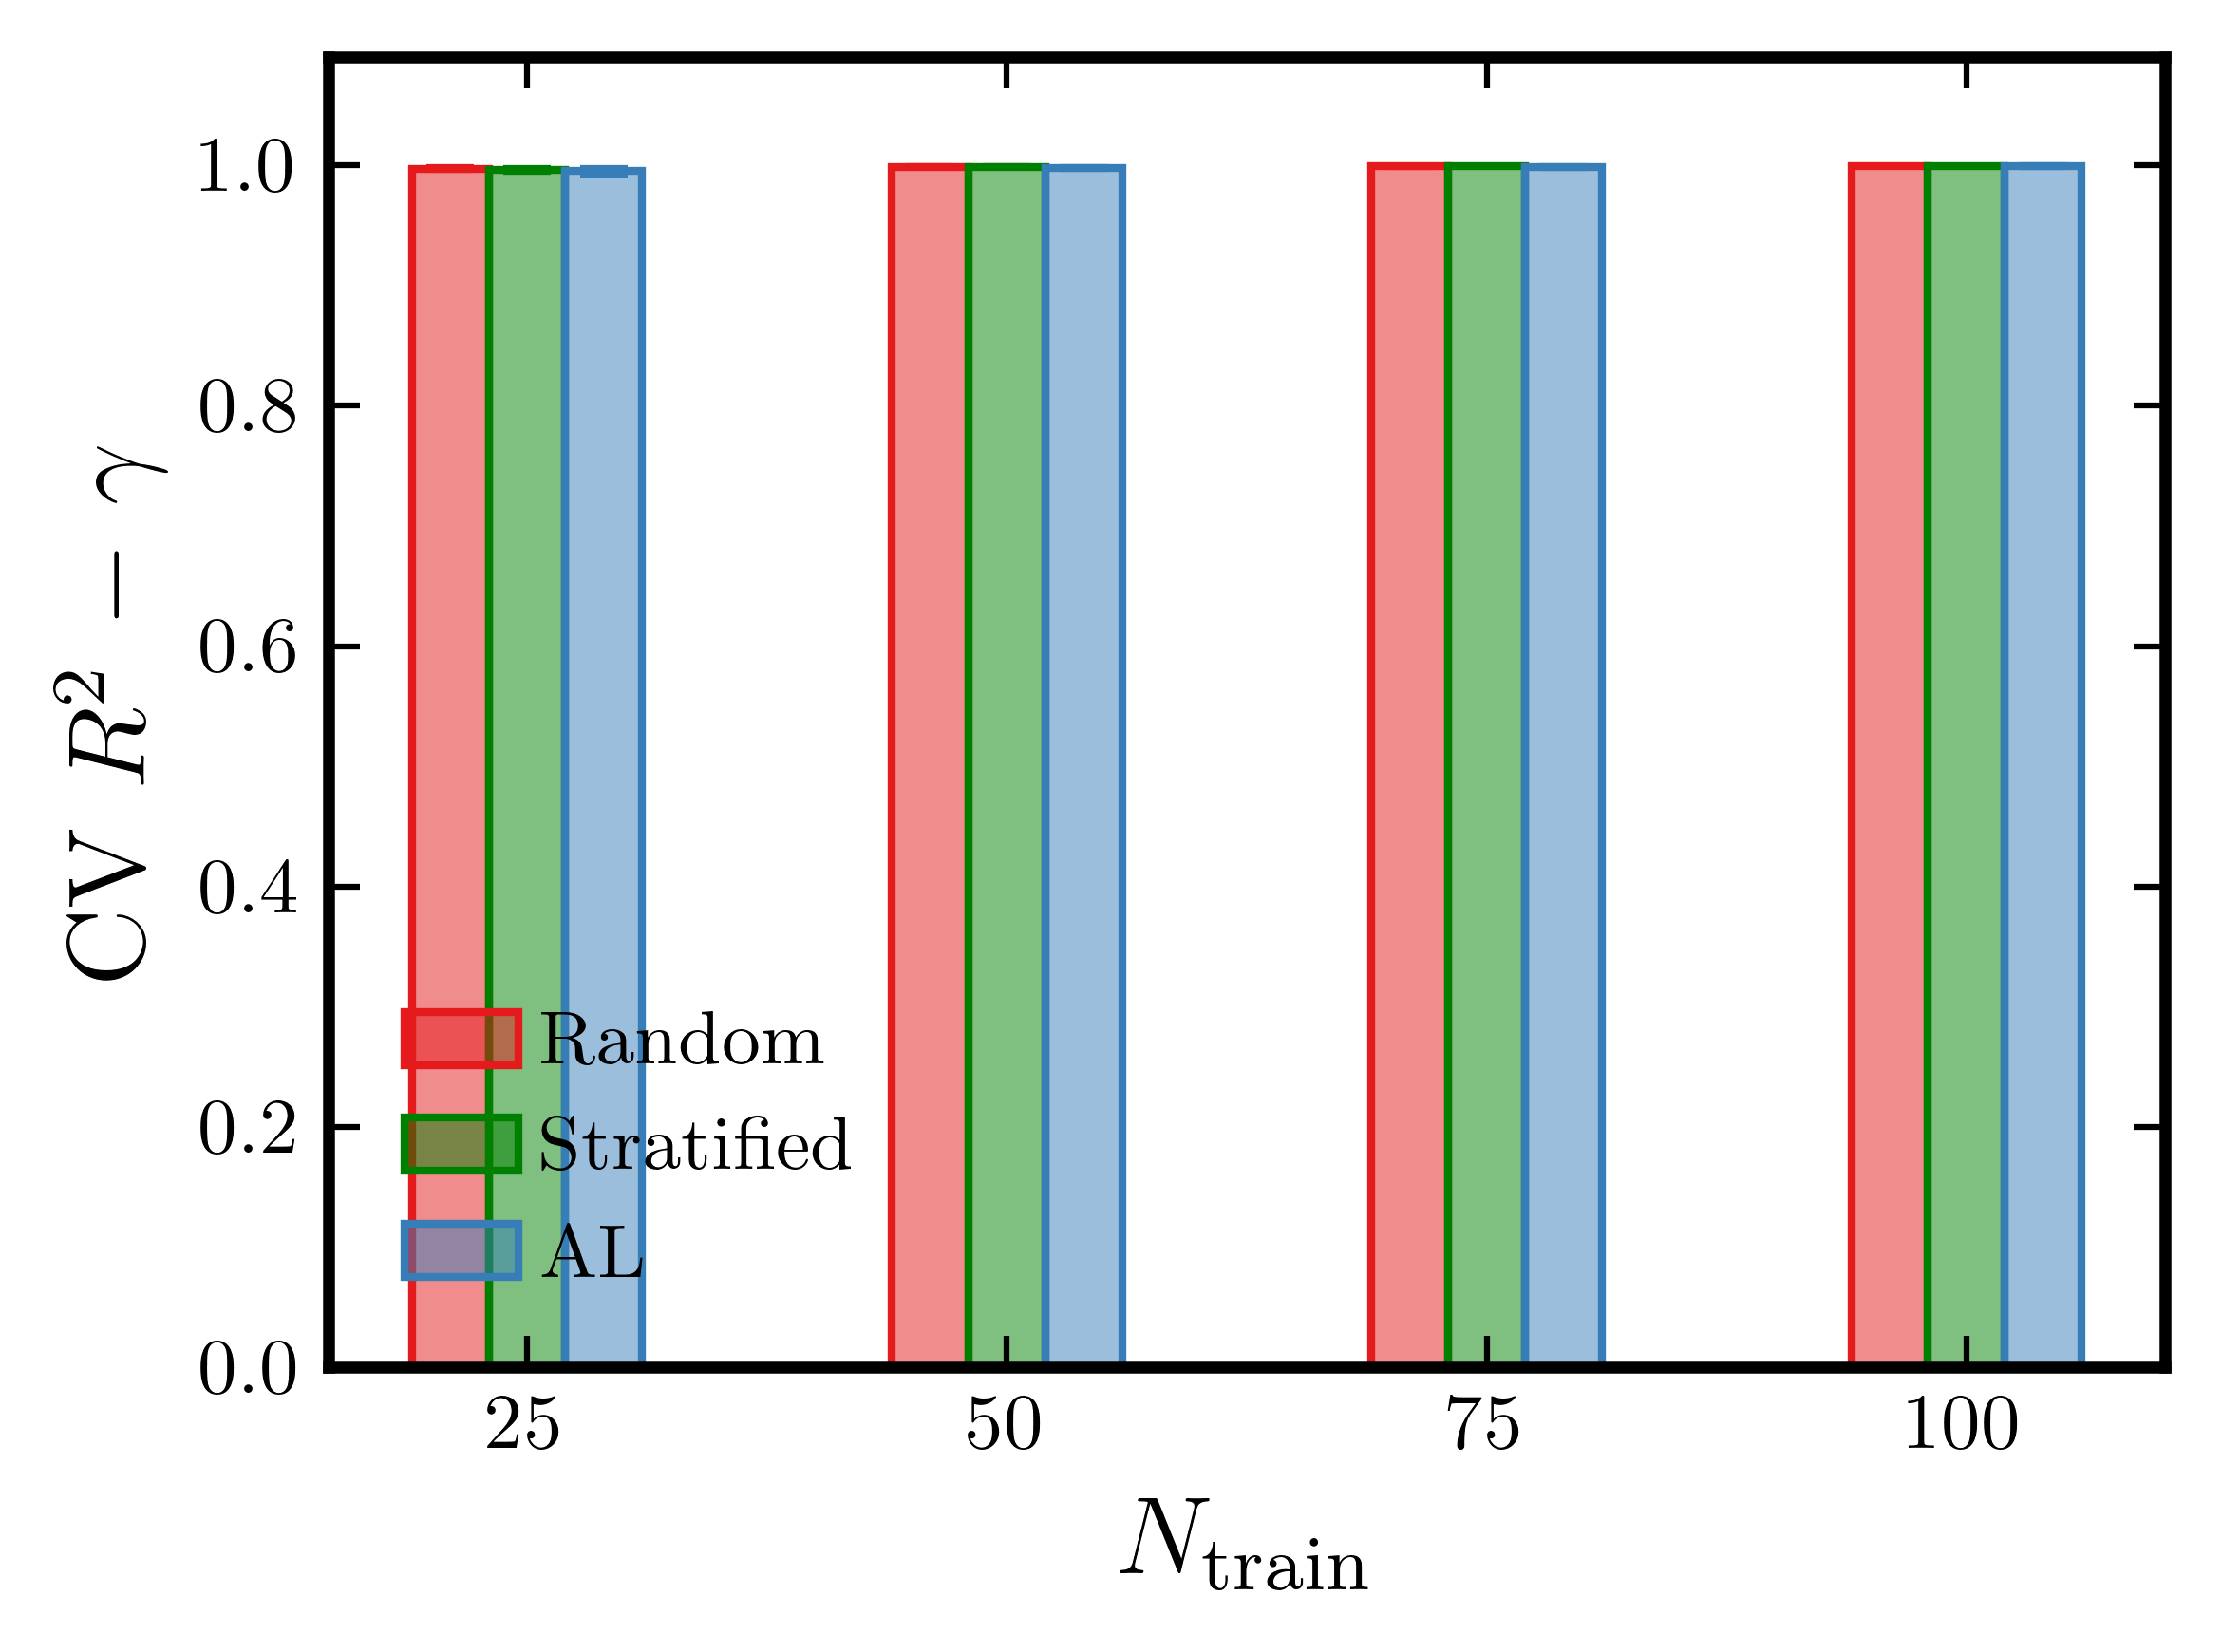

In [15]:
# CV R² — gamma, raw values, grouped bars
fig, ax = plot_init(w=4, h=3)
sub = df_plot[df_plot["target"] == "gamma"]

for i, method in enumerate(METHOD_ORDER):
    grp = sub[sub["method"] == method].sort_values("N_train")
    xs = grp["N_train"].values
    offset = (i - (len(METHOD_ORDER) - 1) / 2) * BAR_WIDTH

    ax.bar(
        xs + offset, grp["r2_y"].values, width=BAR_WIDTH,
        yerr=grp["r2_err"].values,
        color=facecolor_cycle[i], edgecolor=color_cycle[i], linewidth=linewidth,
        capsize=capsize,
        error_kw={"elinewidth": linewidth, "ecolor": color_cycle[i], "capthick": markeredgewidth}, linestyle='-',
        label=METHOD_LABELS[method],
    )

ax.set_xticks(SIZES)
ax.set_xlabel(r"$N_{\mathrm{train}}$", fontsize=LABEL_FS)
ax.set_ylabel(r"$\mathrm{CV}\ R^{2}\ {-}\ \gamma$", fontsize=LABEL_FS)
ax.set_ylim(0.0, 1.09)
ax.xaxis.set_minor_locator(plt.NullLocator())
ax.tick_params(axis='both', which='major', labelsize=TICK_FS)
style_legend(ax, loc="best", ncol=1, frame=False, fontsize=LEGEND_FS)
fig.tight_layout()
save_plot(fig, "cv_R2_gamma", folder=os.path.join(BASE, "PLOTS"))
print("Saved --> PLOTS/cv_R2_gamma.png / .pdf")
plt.show()

Saved --> PLOTS/cv_MAE_gamma.png / .pdf


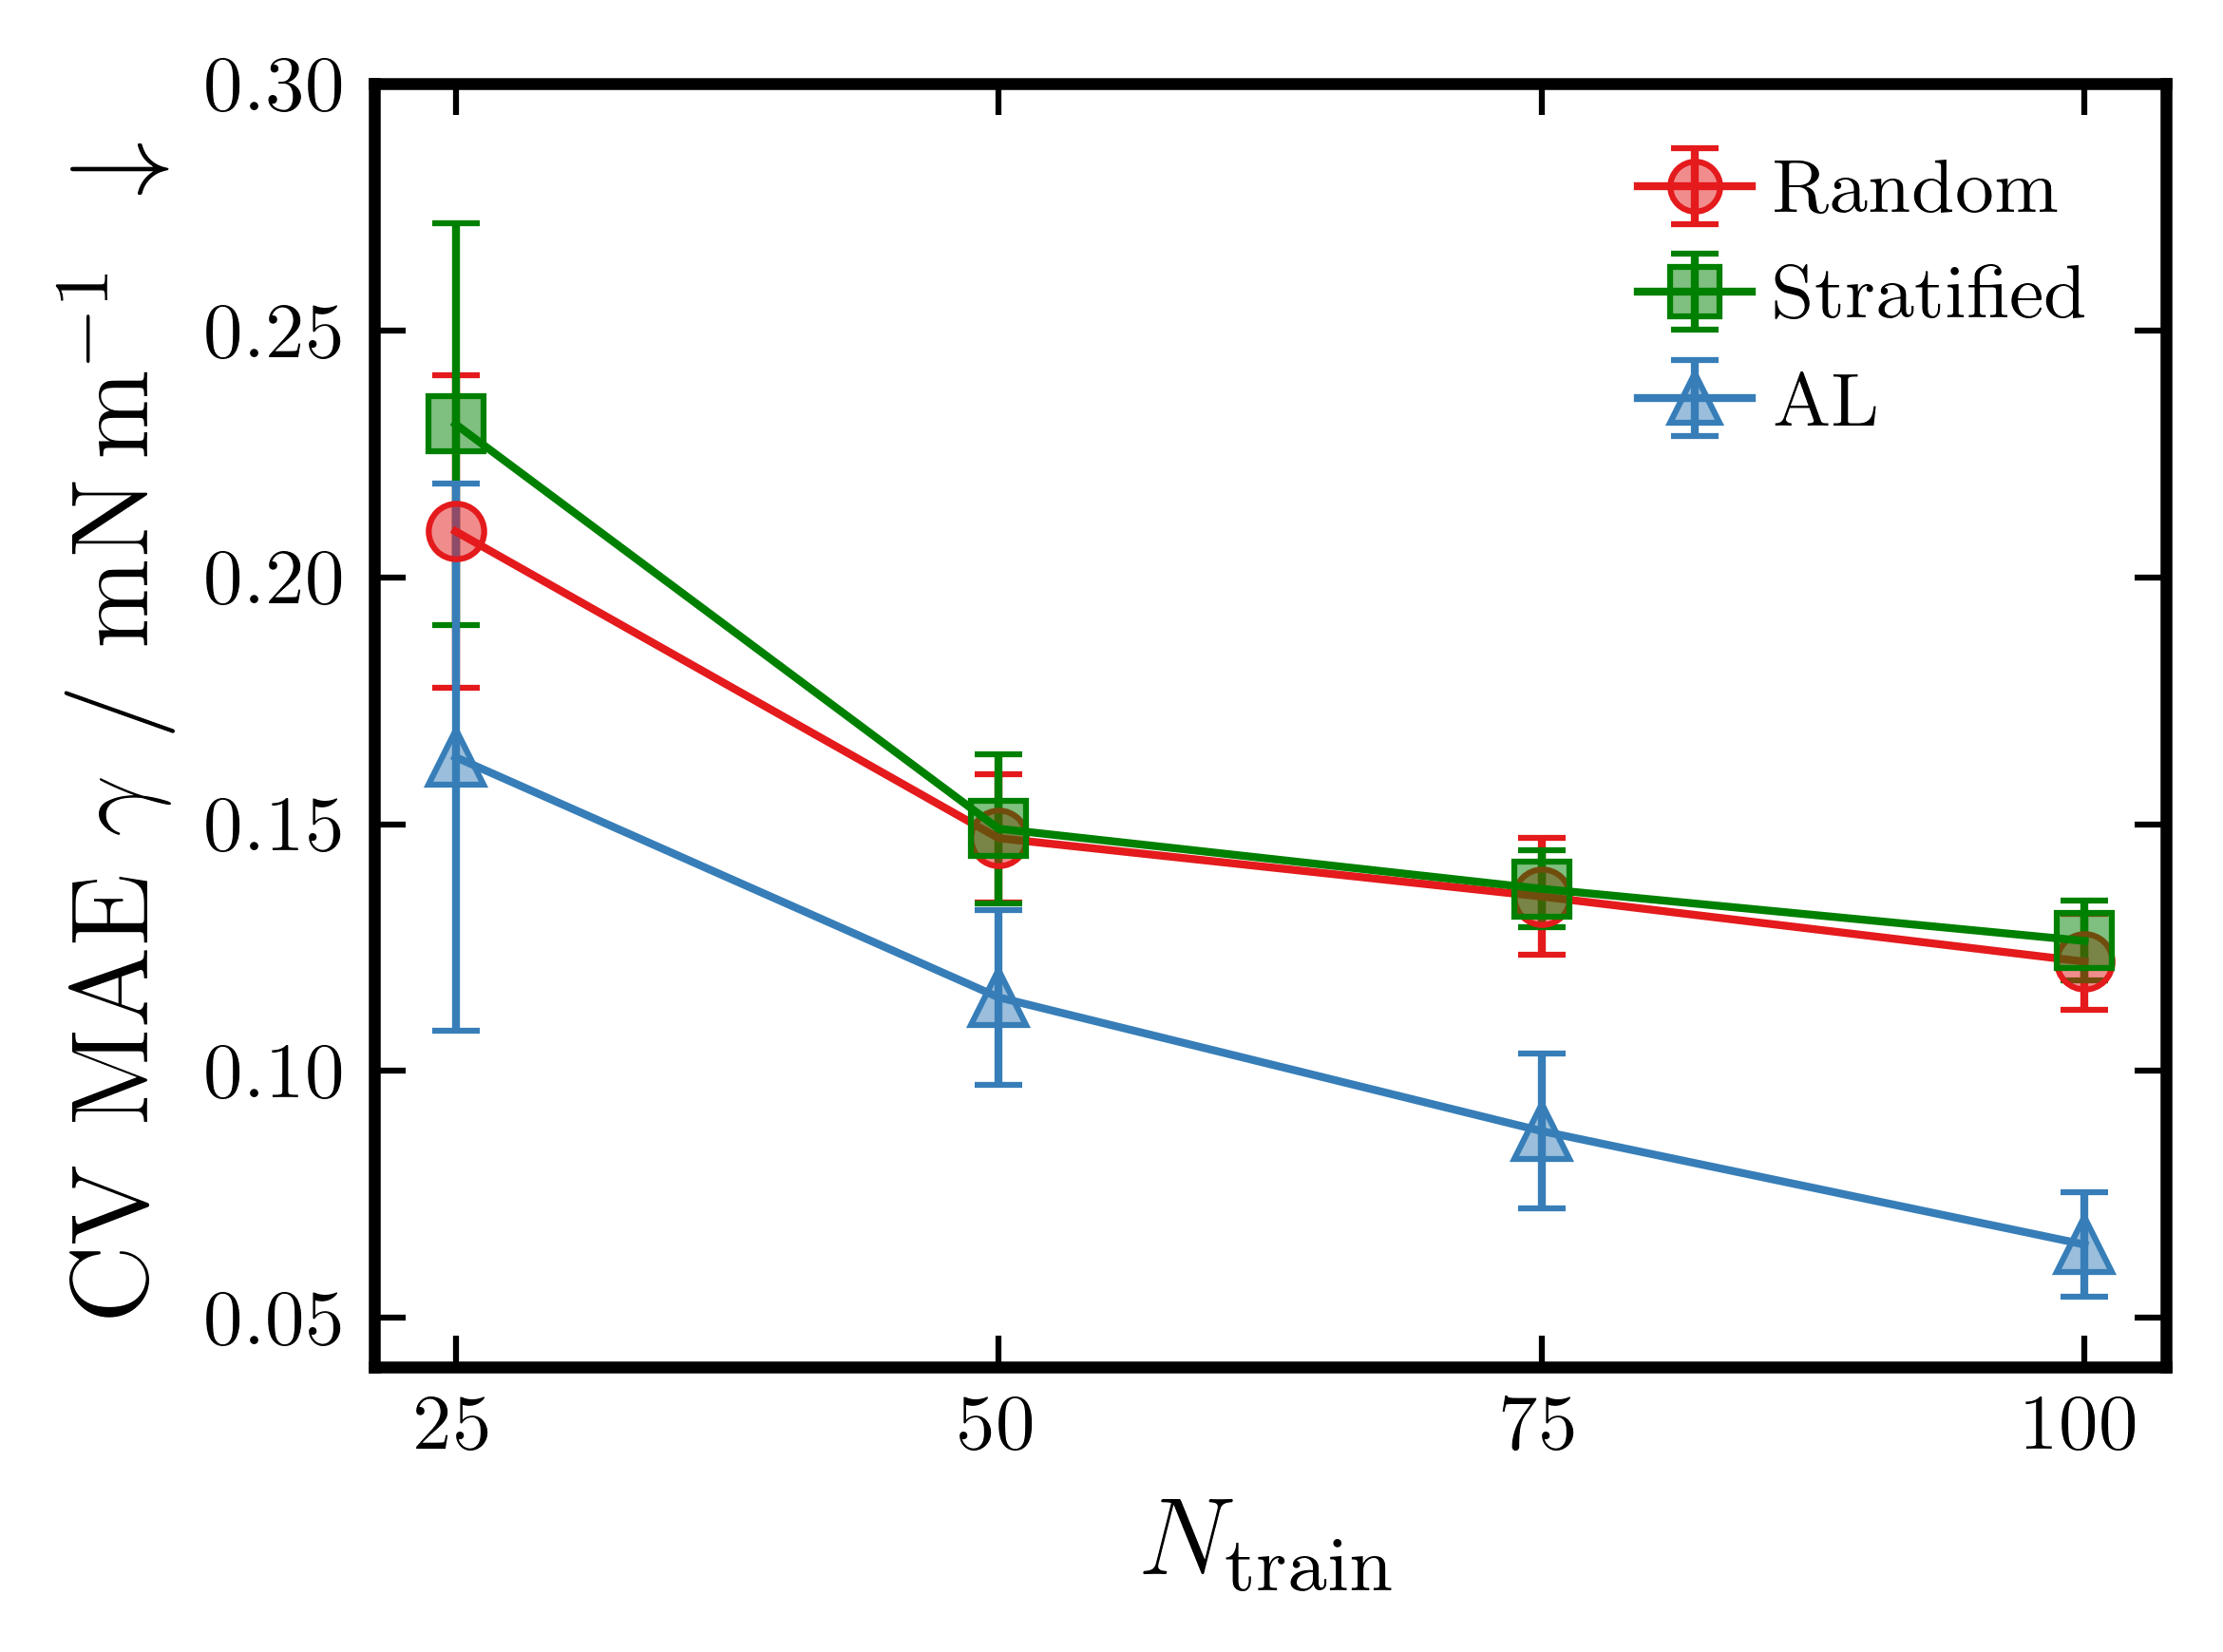

In [22]:
# CV MAE — gamma
fig, ax = plot_init(w=4, h=3)
sub = df_plot[df_plot["target"] == "gamma"]

for i, method in enumerate(METHOD_ORDER):
    grp = sub[sub["method"] == method].sort_values("N_train")
    grp = grp.dropna(subset=["mae_y", "mae_err"])
    if grp.empty:
        continue
    ax.errorbar(
        grp["N_train"].values, grp["mae_y"].values, yerr=grp["mae_err"].values,
        color=color_cycle[i], marker=marker_cycle[i], markersize=markersize,
        markeredgewidth=markeredgewidth, markeredgecolor=color_cycle[i],
        markerfacecolor=facecolor_cycle[i], linewidth=linewidth,
        capsize=capsize, label=METHOD_LABELS[method], linestyle='-',
    )

ax.set_xticks(SIZES)
ax.set_xlabel(r"$N_{\mathrm{train}}$", fontsize=LABEL_FS)
ax.set_ylabel(r"$\mathrm{CV\ MAE}\ \gamma\ /\ \mathrm{mN}\,\mathrm{m}^{-1}\ \downarrow$", fontsize=LABEL_FS)
ax.set_ylim(0.04, 0.3)  # shared y-axis across TabPFN/XGB for gamma MAE
ax.set_yticks(np.arange(0.05, 0.31, 0.05))
ax.xaxis.set_minor_locator(plt.NullLocator())
ax.tick_params(axis='both', which='major', labelsize=TICK_FS)
style_legend(ax, loc="best", ncol=1, frame=False, fontsize=LEGEND_FS)
fig.tight_layout()
save_plot(fig, "cv_MAE_gamma", folder=os.path.join(BASE, "PLOTS"))
print("Saved --> PLOTS/cv_MAE_gamma.png / .pdf")
plt.show()
